# Laboratorium 1 - dodatkowo (z zaocznych)
## Część 1

In [1]:
%%file producer.py
from kafka import KafkaProducer
import json, random, time
from datetime import datetime

producer = KafkaProducer(
    bootstrap_servers='broker:9092',
    value_serializer=lambda v: json.dumps(v).encode('utf-8')
)

sklepy = ['Warszawa', 'Kraków', 'Gdańsk', 'Wrocław']
kategorie = ['elektronika', 'odzież', 'żywność', 'książki']

def generate_transaction():
    return {
        'tx_id': f'TX{random.randint(1000,9999)}',
        'user_id': f'u{random.randint(1,20):02d}',
        'amount': round(random.uniform(5.0, 5000.0), 2),
        'store': random.choice(sklepy),
        'category': random.choice(kategorie),
        'timestamp': datetime.now().isoformat(),
    }

for i in range(1000):
    tx = generate_transaction()
    producer.send('transactions', value=tx)
    print(f"[{i+1}] {tx['tx_id']} | {tx['amount']:.2f} PLN | {tx['store']}")
    time.sleep(0.5)

producer.flush()
producer.close()

Writing producer.py


### Zadanie 1.1
Zmień producenta tak, by 5% transakcji było podejrzanych: - kwota > 3000 PLN - kategoria = ‘elektronika’ - godzina nocna (dodaj pole hour z losową wartością 0–5)

In [2]:
%%file producer.py
from kafka import KafkaProducer
import json, random, time
from datetime import datetime

producer = KafkaProducer(
    bootstrap_servers='broker:9092',
    value_serializer=lambda v: json.dumps(v).encode('utf-8')
)

sklepy = ['Warszawa', 'Kraków', 'Gdańsk', 'Wrocław']
kategorie = ['elektronika', 'odzież', 'żywność', 'książki']

def generate_transaction():
    if random.random() < 0.05:
        amount = round(random.uniform(3000.01, 5000.0), 2)
        category = 'elektronika'
        hour = random.randint(0, 5)
    else:
        amount = round(random.uniform(5.0, 3000.0), 2)
        category = random.choice(kategorie)
        hour = random.randint(0, 23)

    return {
        'tx_id': f'TX{random.randint(1000,9999)}',
        'user_id': f'u{random.randint(1,20):02d}',
        'amount': amount,
        'store': random.choice(sklepy),
        'category': category,
        'hour': hour,
        'timestamp': datetime.now().isoformat(),
    }

for i in range(1000):
    tx = generate_transaction()
    producer.send('transactions', value=tx)
    print(f"[{i+1}] {tx['tx_id']} | {tx['amount']:.2f} PLN | {tx['store']}")
    time.sleep(0.5)

producer.flush()
producer.close()

Overwriting producer.py


## Część 2
### Zadanie 2.1
Napisz konsumenta, który wypisuje tylko transakcje z amount > 1000.

In [6]:
%%file consumer_filter.py
from kafka import KafkaConsumer
import json

consumer = KafkaConsumer(
    'transactions',
    bootstrap_servers='broker:9092',
    # auto_offset_reset='earliest', # to powoduje, ze consumer_filter analizuje tez historyczne dane (zakomentowane, bo dodane dodatkowo)
    value_deserializer=lambda x: json.loads(x.decode('utf-8'))
)

for message in consumer:
    if message.value['amount'] > 1000:
        print(f'!!! ALERT !!! {message.value}')

Writing consumer_filter.py


### Zadanie 2.2
Napisz konsumenta, który dodaje pole risk_level: - amount > 3000 → “HIGH” - amount > 1000 → “MEDIUM” - reszta → “LOW”

In [10]:
%%file consumer_enrich.py
from kafka import KafkaConsumer
import json

consumer = KafkaConsumer(
    'transactions',
    bootstrap_servers='broker:9092',
    value_deserializer=lambda x: json.loads(x.decode('utf-8'))
)

for message in consumer:    
    if message.value['amount'] > 3000:
        message.value['risk_level'] = 'HIGH'
    elif message.value['amount'] > 1000:
        message.value['risk_level'] = 'MEDIUM'
    else:
        message.value['risk_level'] = 'LOW'
        
    print(message.value)

Writing consumer_enrich.py


## Część 3
### Zadanie 3.1
Napisz konsumenta, który liczy transakcje i sumy per sklep. Wypisz podsumowanie co 10 wiadomości.

In [12]:
%%file consumer_count.py
from kafka import KafkaConsumer
from collections import Counter, defaultdict
import json

consumer = KafkaConsumer(
    'transactions',
    bootstrap_servers='broker:9092',
    auto_offset_reset='earliest',
    group_id='count-group',
    value_deserializer=lambda x: json.loads(x.decode('utf-8'))
)

store_counts = Counter()
total_amount = defaultdict(float)
msg_count = 0

for message in consumer:
    store = message.value['store']
    amount = message.value['amount']

    store_counts[store] += 1
    
    total_amount[store] += amount
    
    msg_count += 1

    if msg_count % 10 == 0:
        print(f"\n--- PODSUMOWANIE (po {msg_count} wiadomościach) ---")
        print(f"{'Sklep':<15} | {'Liczba TX':<10} | {'Suma (PLN)':<12}")
        print("-" * 45)
        for s in sorted(store_counts.keys()):
            print(f"{s:<15} | {store_counts[s]:<10} | {total_amount[s]:>10.2f}")
        print("-" * 45)

Writing consumer_count.py


## Część 4
### Zadanie 4.1
Napisz funkcję, która przyznaje punkty za podejrzane cechy:
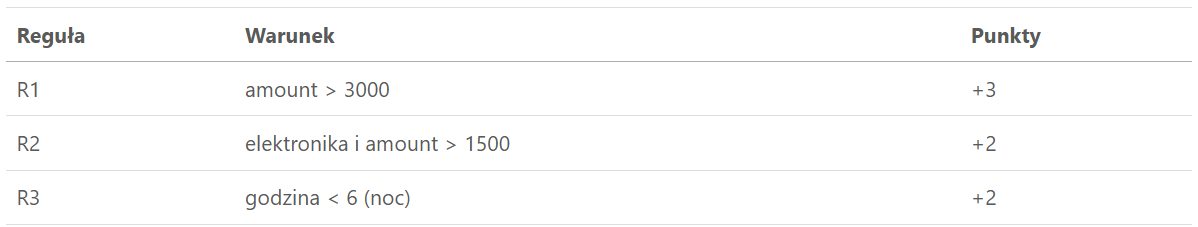
Jeśli suma >= 3 → PODEJRZANA.

In [18]:
def score_transaction(tx):
    score = 0
    rules = []
    
   # R1: kwota > 3000 (+3 pkt)
    if tx['amount'] > 3000:
        score += 3
        rules.append('R1')
        
    # R2: elektronika i kwota > 1500
    if tx['category'] == 'elektronika' and tx['amount'] > 1500:
        score += 2
        rules.append('R2')
        
    # R3: godzina nocna < 6
    hour = int(tx['timestamp'][11:13])
    
    if hour < 6:
        score += 2
        rules.append('R3')
        
    return score, rules

# Test
test_tx = {'tx_id': 'TX999', 'amount': 4500.0, 'category': 'elektronika',
           'timestamp': '2026-04-01T03:15:00'}
print(score_transaction(test_tx))  # powinno dać score >= 5

(7, ['R1', 'R2', 'R3'])


### Zadanie 4.3
Połącz scoring z konsumentem Kafki. Podejrzane transakcje wyślij do nowego tematu alerts.

In [20]:
%%file scoring_consumer.py
from kafka import KafkaConsumer, KafkaProducer
import json

consumer = KafkaConsumer('transactions', bootstrap_servers='broker:9092',
    auto_offset_reset='earliest', group_id='scoring-group',
    value_deserializer=lambda x: json.loads(x.decode('utf-8')))

alert_producer = KafkaProducer(bootstrap_servers='broker:9092',
    value_serializer=lambda v: json.dumps(v).encode('utf-8'))

# TWÓJ KOD
# Dla każdej transakcji: scoruj, jeśli >= 3: wyślij do 'alerts' i wypisz ALERT

def score_transaction(tx):
    score = 0
    rules = []
    
   # R1: kwota > 3000 (+3 pkt)
    if tx['amount'] > 3000:
        score += 3
        rules.append('R1')
        
    # R2: elektronika i kwota > 1500
    if tx['category'] == 'elektronika' and tx['amount'] > 1500:
        score += 2
        rules.append('R2')
        
    # R3: godzina nocna < 6
    hour = int(tx['timestamp'][11:13])
    
    if hour < 6:
        score += 2
        rules.append('R3')
        
    return score, rules

consumer = KafkaConsumer(
    'transactions',
    bootstrap_servers='broker:9092',
    auto_offset_reset='earliest',
    group_id='count-group',
    value_deserializer=lambda x: json.loads(x.decode('utf-8'))
)

alert_producer = KafkaProducer(
    bootstrap_servers='broker:9092',
    value_serializer=lambda v: json.dumps(v).encode('utf-8')
)

for message in consumer:
    tx = message.value
    
    score, rules = score_transaction(tx)
    
    if score >= 3:
        tx['score'] = score
        tx['rules'] = rules
        
        alert_producer.send('alerts', value=tx)
        
        print(f"!!! ALERT !!! ID: {tx['tx_id']} | Score: {score} | Rules: {rules}")

alert_producer.flush()

Writing scoring_consumer.py
